In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Load Dataset

In [3]:
df= pd.read_csv('dataSP23.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


<h2>Data Preprocessing

In [4]:
df = df.drop(['id','name', 'host_id', 'host_name', 'last_review', 'reviews_per_month', 'number_of_reviews', 'neighbourhood' ], axis=1)
#  

In [5]:
df.isnull().sum()

neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df.shape)

(27379, 8)


# Checking for Outliers

In [8]:
df.dtypes

neighbourhood_group                object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [9]:
cat = df.select_dtypes(include='object').columns
num = df.select_dtypes(include='number').columns

print(cat)
num

Index(['neighbourhood_group', 'room_type'], dtype='object')


Index(['latitude', 'longitude', 'price', 'minimum_nights',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

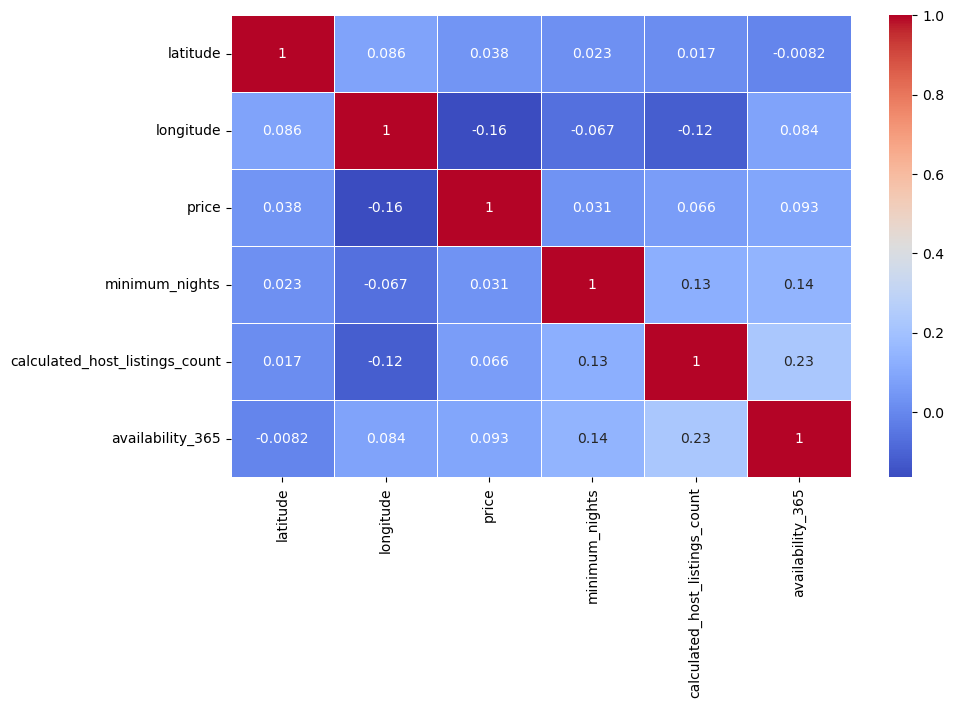

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num].corr(), annot=True, cmap='coolwarm',linewidths=0.5)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_6996\2864050345.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


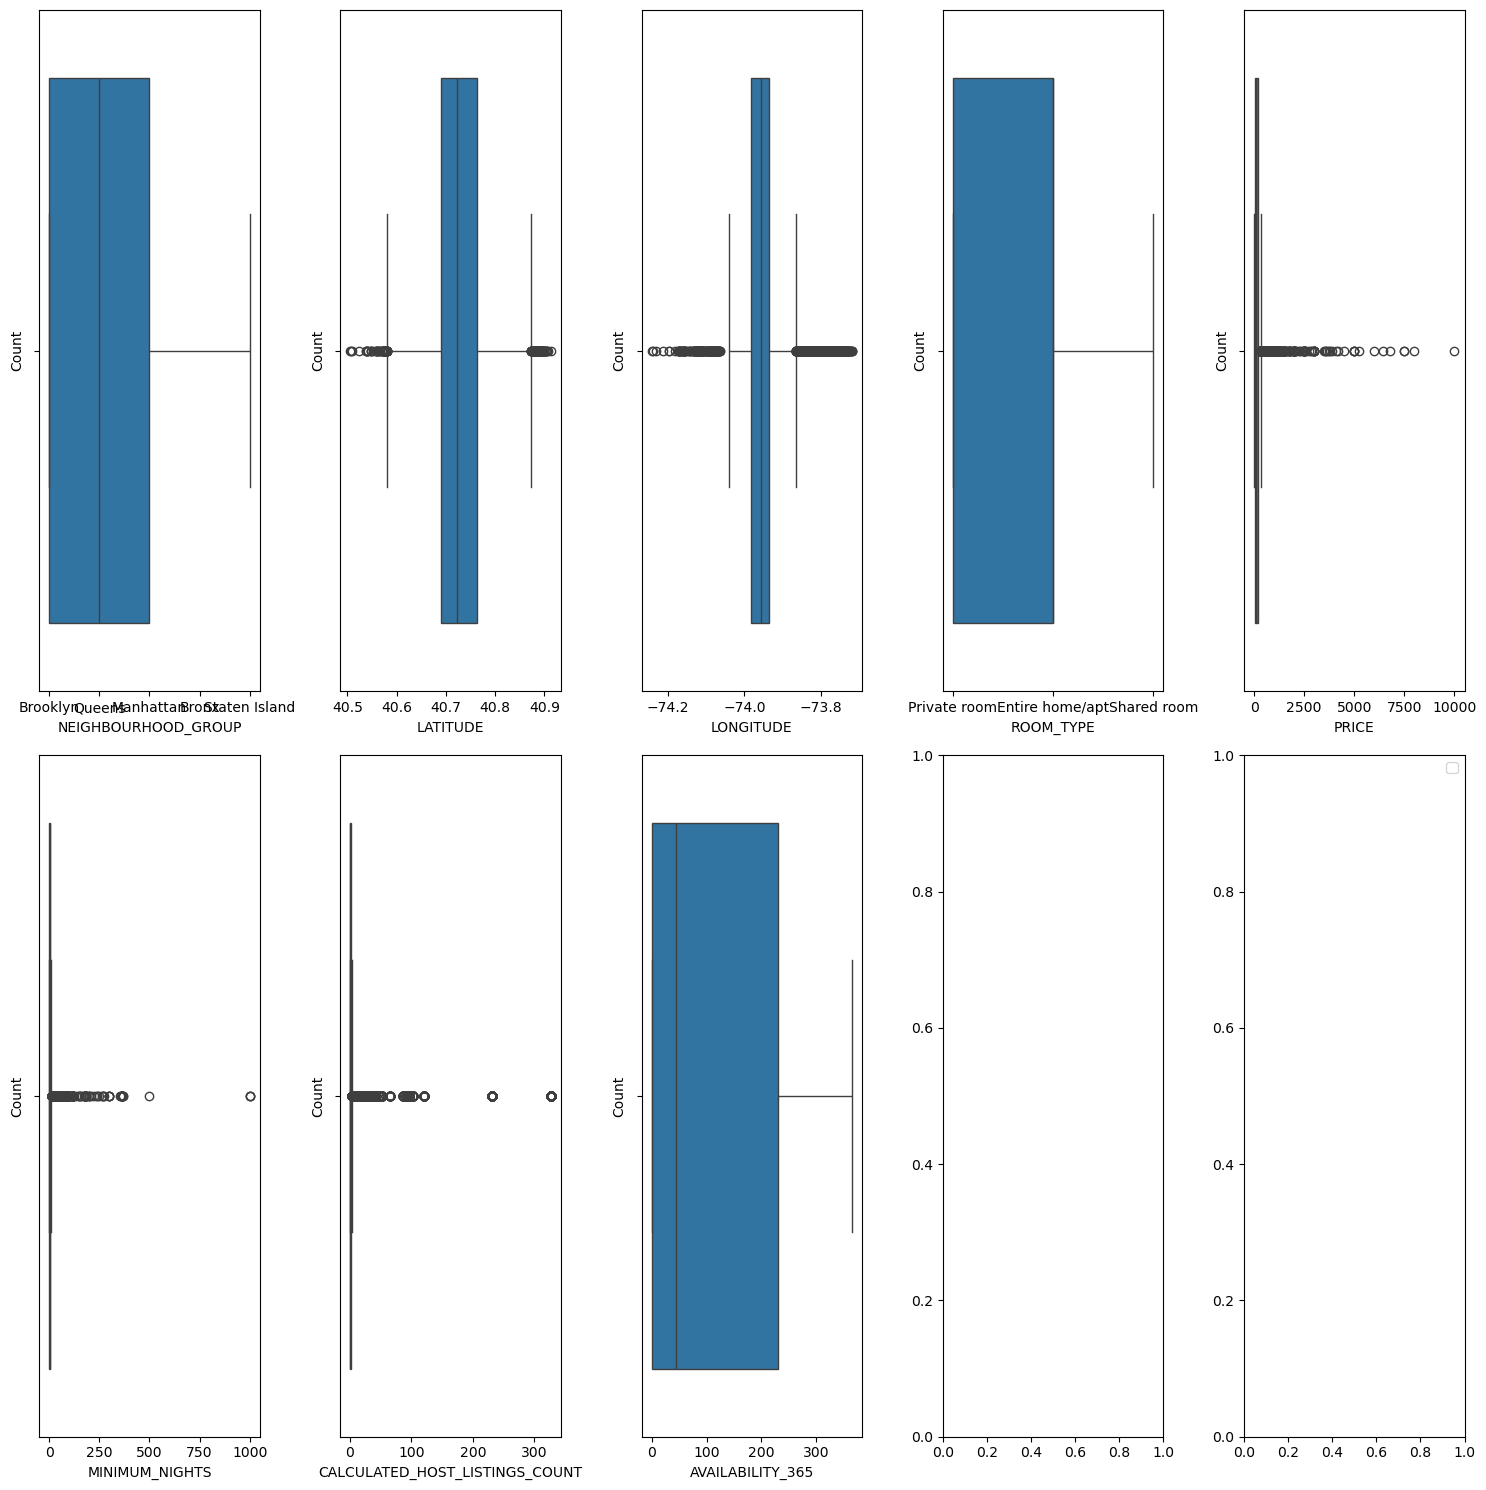

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 15))
axes = axes.flatten()
for i , v in enumerate(df):
    sns.boxplot(x=df[v], ax= axes[i])
    axes[i].set_xlabel(v.upper())
    axes[i].set_ylabel('Count')
plt.legend()
plt.tight_layout()

plt.show()

In [12]:
def check_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3 - q1
    
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [13]:
check_outliers(df, 'price')

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
17,Manhattan,40.75403,-73.96714,Entire home/apt,714,28,49,250
35,Manhattan,40.73722,-74.00263,Entire home/apt,1500,3,1,54
42,Manhattan,40.74478,-73.98442,Entire home/apt,349,4,1,255
56,Manhattan,40.76515,-73.98586,Entire home/apt,389,1,1,0
75,Manhattan,40.75000,-73.99637,Entire home/apt,395,3,1,0
...,...,...,...,...,...,...,...,...
27286,Manhattan,40.76955,-73.95988,Entire home/apt,589,6,1,4
27326,Brooklyn,40.65716,-73.97550,Entire home/apt,450,4,2,87
27331,Manhattan,40.71895,-73.99793,Entire home/apt,5250,1,1,0
27355,Manhattan,40.74775,-73.99167,Entire home/apt,999,2,1,0


In [14]:
print(df['room_type'].unique())
print(df['neighbourhood_group'].unique())


['Private room' 'Entire home/apt' 'Shared room']
['Brooklyn' 'Queens' 'Manhattan' 'Bronx' 'Staten Island']


# Label Encoding Textual data to Numerical data


In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

label_encoder = LabelEncoder()
onehot_encoder = OneHotEncoder()


onehot_encoder = OneHotEncoder(sparse_output=False)

for col in ['neighbourhood_group', 'room_type']:
    encoded = onehot_encoder.fit_transform(df[[col]])
    encoded_cols = onehot_encoder.get_feature_names_out([col])
    df = pd.concat(
        [df.drop(columns=[col]),
        pd.DataFrame(encoded, columns=encoded_cols, index=df.index)],
        axis=1
    )


# df = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type', 'neighbourhood'], drop_first=True, dtype=int)

In [16]:
df

,latitude,longitude,price,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,40.69591,-73.96284,58,2,1,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,40.68769,-73.97490,99,5,1,250,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,40.67667,-73.91750,180,2,1,74,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,40.74340,-73.90588,50,1,2,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,40.66600,-73.99020,210,4,1,20,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27374,40.74735,-73.99974,585,3,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
27375,40.84499,-73.91157,60,5,1,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
27376,40.63981,-73.90211,80,3,2,365,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
27377,40.73212,-73.98247,150,2,1,36,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [17]:
# split data into 3 set: train , test, safe
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)
X_train, X_safe, y_train, y_safe = train_test_split(X_train, y_train, train_size=0.8, random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
y_pred = lr.predict(X_test)
y_pred

array([150,  50, 100, ..., 150, 175, 250], shape=(5476,))

In [21]:
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error

print(f"R2 Score {r2_score(y_test, y_pred)}")
print(f"Accuracy Score {lr.score(X_test, y_test)}")
print(f"Mean Squared Error {mean_squared_error(y_test, y_pred) / 2}")

R2 Score 0.10172012488705062
Accuracy Score 0.07797662527392257
Mean Squared Error 14170.607377647919


# Visualisation

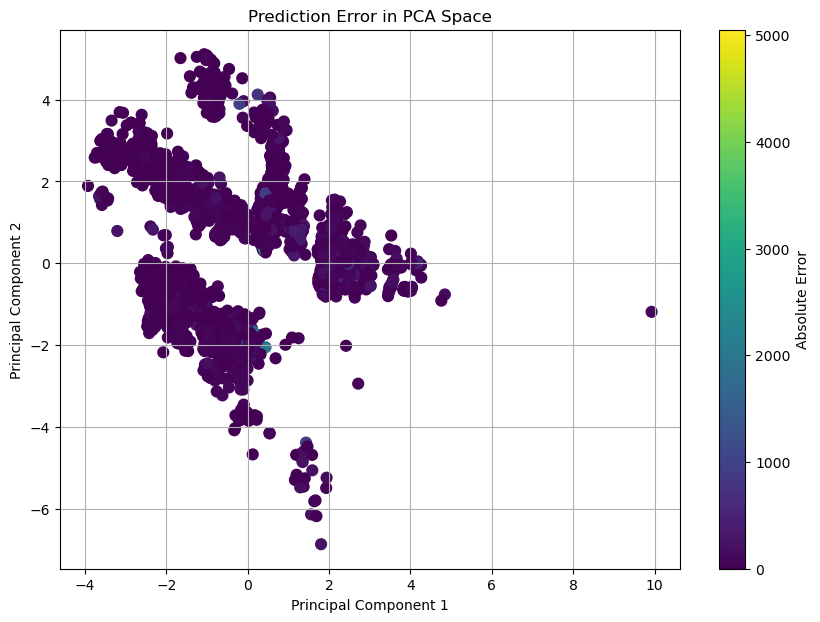

In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA on the test features
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Absolute prediction error
error = np.abs(y_test - y_pred)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=error,
    cmap='viridis',
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Prediction Error in PCA Space")
plt.colorbar(label="Absolute Error")
plt.grid(True)
plt.show()